In [ ]:
# # --- 📦 Install Dependencies ---
# !pip install langchain -q
# !pip install langchain-community -q 
# !pip install langchain_mistralai -q
# !pip install langserve -q
# !pip install langgraph -q
# !pip install transformers -q
# !pip install rizaio -q 
# !pip install --upgrade typing_extensions -q

In [ ]:
# 1. Import required modules
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph
from langchain_mistralai import ChatMistralAI
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

In [2]:
import os
os.environ["MISTRAL_API_KEY"] = "lGSUJ1oM7Eav2Kl7YAYqr6rxFNzNZkXf"

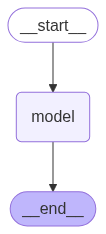

In [ ]:
# 2. Load the LLM model
llm = ChatMistralAI(model="ministral-8b-latest")

# 3. Define the workflow (StateGraph)
workflow = StateGraph(state_schema=MessagesState)

# 4. Define the model node (do the work)
def call_model(state: MessagesState):
    start_prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content="You are a protocol droid designed for assisting sentient beings in writing code."),
        MessagesPlaceholder("messages")
    ])
    model = start_prompt | llm
    return {"messages": model.invoke({"messages": state["messages"]})}

# 5. Build the graph (nodes + edges)
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# 6. Compile with in-memory storage
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# 7. Visualize the graph
display(Image(app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)))


In [ ]:
# Prepare a message
config = {"configurable": {"thread_id": "abc123"}}
input_messages = [HumanMessage("Can you tell me what is 3+5 using Python?")]

# Run the workflow
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Certainly! In Python, you can perform arithmetic operations using the `+` operator. To calculate the sum of 3 and 5, you can write the following code:

```python
result = 3 + 5
print(result)
```

When you run this code, it will output:

```
8
```

So, 3 + 5 equals 8 in Python.



## Integrate Tools in our application

Many AI applications interact directly with humans. In these cases, it is appropriate for models to respond in natural language. But what about cases where we want a model to also interact directly with systems, such as databases or an API? These systems often have a particular input schema; for example, APIs frequently have a required payload structure. This need motivates the concept of tool calling. You can use tool calling to request model responses that match a particular schema.

Here's a schema taken from langchain's documentation to illustrate how tools work:

![tools](https://full-stack-assets.s3.eu-west-3.amazonaws.com/images/M10-llm/tool_calling_components-bef9d2bcb9d3706c2fe58b57bf8ccb60.png)


```python
def multiply(a: int, b: int) -> int:
"""Multiply a and b.

Args:
    a: first int
    b: second int
"""
return a * b



In [11]:
# Get your API key directly here: https://dashboard.riza.io/
os.environ["RIZA_API_KEY"] = "lGSUJ1oM7Eav2Kl7YAYqr6rxFNzNZkXf"
os.environ["MISTRAL_API_KEY"] = "lGSUJ1oM7Eav2Kl7YAYqr6rxFNzNZkXf"

In [12]:
# 1. Import Riza Tool
from langchain_community.tools.riza.command import ExecPython

# 2. Bind the tool to the LLM
#llm = ChatMistralAI(model="mistral-small-latest")
llm = ChatMistralAI(model="open-mistral-7b")

tools = [ExecPython()]
powered_llm = llm.bind_tools(tools)

# 3. Try a tool invocation
result = powered_llm.invoke("Execute this python code: ```python print(3+5)```")
print(result.tool_calls)
result.pretty_print()

[{'name': 'riza_exec_python', 'args': {'code': 'print(3+5)'}, 'id': 'UZIWtTY2R', 'type': 'tool_call'}]
================================== Ai Message ==================================
Tool Calls:
  riza_exec_python (UZIWtTY2R)
 Call ID: UZIWtTY2R
  Args:
    code: print(3+5)


In [ ]:
!pip install pyppeteer
!pip install nest_asyncio -q

# Apply patch
import nest_asyncio
nest_asyncio.apply()

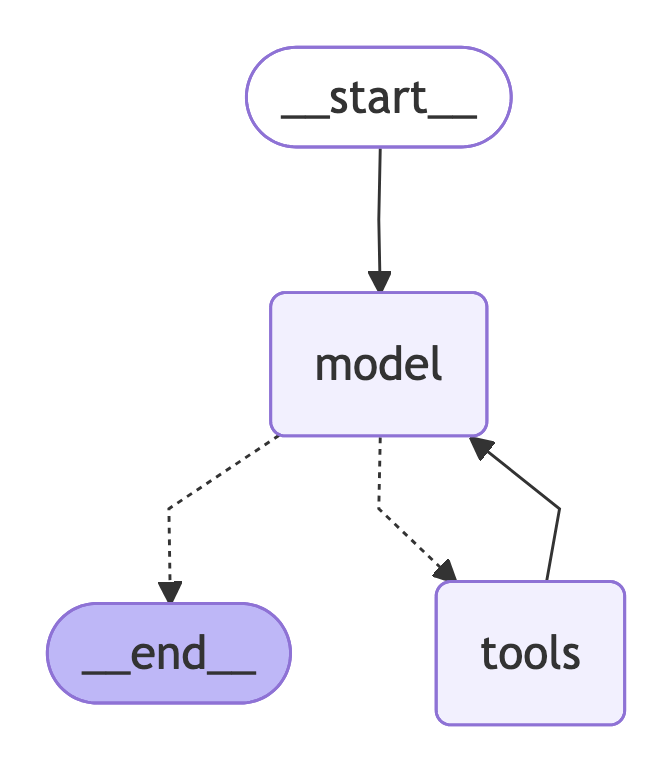

In [13]:
from langgraph.prebuilt import ToolNode, tools_condition

os.environ["MISTRAL_API_KEY"] = "lGSUJ1oM7Eav2Kl7YAYqr6rxFNzNZkXf"


# Recreate the graph with tool support
workflow = StateGraph(state_schema=MessagesState)

def call_model(state: MessagesState):
    start_prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content="You are a protocol droid designed for assisting sentient beings in writing code."),
        MessagesPlaceholder("messages")
    ])
    model = start_prompt | powered_llm
    return {"messages": model.invoke({"messages": state["messages"]})}

# Add nodes and conditional edges
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)
workflow.add_node("tools", ToolNode(tools=tools))
workflow.add_conditional_edges("model", tools_condition)
workflow.add_edge("tools", "model")

# Compile with memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# Visualize the graph again
display(Image(app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))


In [14]:
import os
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import SystemMessage
from langchain_mistralai import ChatMistralAI
from langchain_community.tools.riza.command import ExecPython

# 1. Setup API Key
os.environ["MISTRAL_API_KEY"] = "lGSUJ1oM7Eav2Kl7YAYqr6rxFNzNZkXf"

# 2. Define the model and bind tools (ExecPython)
llm = ChatMistralAI(model="open-mistral-7b")
tools = [ExecPython()]
powered_llm = llm.bind_tools(tools)

# 3. Build the LangGraph workflow
workflow = StateGraph(state_schema=MessagesState)

# 4. Define the model node
def call_model(state: MessagesState):
    start_prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content="You are a protocol droid designed for assisting sentient beings in writing and executing Python code."),
        MessagesPlaceholder("messages")
    ])
    model = start_prompt | powered_llm
    return {"messages": model.invoke({"messages": state["messages"]})}

# 5. Register nodes and conditional execution for tools
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)
workflow.add_node("tools", ToolNode(tools=tools))  # ToolNode executes tool calls
workflow.add_conditional_edges("model", tools_condition)
workflow.add_edge("tools", "model")

# 6. Compile the workflow with memory to track conversation state
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)


In [10]:
# from langchain_core.messages import HumanMessage

# # User input requesting Python code execution
# query = """Execute this Python code:

# ```python
# print(3 + 5)
# ```"""

# # Wrap the user input into a HumanMessage
# input_messages = [HumanMessage(query)]

# # Configuration with a thread ID to keep the session state
# config = {"configurable": {"thread_id": "user_python_executor_001"}}

# # Run the workflow with the user message
# output = app.invoke({"messages": input_messages}, config)

# # Display all conversation messages including tool results
# print("\n=== Conversation Output ===")
# for message in output["messages"]:
#     print(f"{message.__class__.__name__}: {message.content}")
